# BCE Logistic Regression — Thực nghiệm Tối ưu hóa

**Mục tiêu:** nghiên cứu cách geometry của BCE ảnh hưởng đến step size và tốc độ hội tụ.

\[
\text{BCE}
\rightarrow H
\rightarrow \kappa,L
\rightarrow GD/SGD/NAG/Newton
\rightarrow L2
\rightarrow \text{convergence}
\rightarrow \text{prediction}
\]

**Kết luận cuối từ lần chạy hiện tại:** Damped Newton là optimizer tốt nhất cho BCE; validation chọn \(\lambda^\star=0\).

## 0. Quy ước

**Làm gì:** dùng trực tiếp `train.csv`, `val.csv`, `test.csv` đã được nhóm preprocessing và cố định.

- Không split, clean hay standardize lại.
- Cùng initialization \(w=0,b=0\).
- Validation dùng để chọn regularization/threshold.
- Test chỉ mở sau khi đã khóa cấu hình.

**Kết luận:** mọi khác biệt trong phần này đến từ tối ưu hóa, không phải do preprocessing khác nhau.

In [1]:
from pathlib import Path
import json
import math
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
)

SEED = 42
TARGET_COL = "Diabetes_binary"

# False = cấu hình dùng cho lần chạy chính thức.
# True = giảm số iteration/epoch để kiểm tra nhanh notebook.
FAST_MODE = False

GD_MAX_ITERS = 120 if FAST_MODE else 500
NAG_MAX_ITERS = 120 if FAST_MODE else 500
NEWTON_MAX_ITERS = 12 if FAST_MODE else 30
SGD_EPOCHS = 5 if FAST_MODE else 20
BATCH_SIZE = 512
GRAD_TOL = 1e-5

OUTPUT_DIR = Path("./bce_experiment_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Notebook tự thử các vị trí phổ biến; không sửa dữ liệu.
CANDIDATE_DATA_DIRS = [
    Path("./data/processed"),
    Path("./upload"),
    Path("."),
]

def resolve_csv(filename):
    for folder in CANDIDATE_DATA_DIRS:
        path = folder / filename
        if path.exists():
            return path
    searched = "\n".join(str(d / filename) for d in CANDIDATE_DATA_DIRS)
    raise FileNotFoundError(
        f"Không tìm thấy {filename}. Đã thử:\n{searched}\n"
        "Hãy đặt 3 frozen CSV vào ./data/processed, ./upload hoặc cùng thư mục notebook."
    )

TRAIN_PATH = resolve_csv("train.csv")
VAL_PATH = resolve_csv("val.csv")

print("TRAIN:", TRAIN_PATH)
print("VAL  :", VAL_PATH)
print("FAST_MODE =", FAST_MODE)

TRAIN: data/processed/train.csv
VAL  : data/processed/val.csv
FAST_MODE = False


## 1. Kiểm tra dữ liệu đầu vào

**Thực nghiệm:** kiểm tra kích thước, số feature và class balance của frozen splits.

**Kết luận:** train có 21 feature; positive ratio giảm từ khoảng 16.3% ở train xuống 15.1% ở validation. Vì dữ liệu mất cân bằng, phần prediction sẽ ưu tiên F1 minority và AUPRC hơn accuracy.

In [2]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

if TARGET_COL not in train_df.columns or TARGET_COL not in val_df.columns:
    raise ValueError(f"Thiếu target column: {TARGET_COL}")

feature_cols = [c for c in train_df.columns if c != TARGET_COL]

if feature_cols != [c for c in val_df.columns if c != TARGET_COL]:
    raise ValueError("Feature schema/order của train và val không giống nhau.")

X_train = train_df[feature_cols].to_numpy(dtype=np.float64)
y_train = train_df[TARGET_COL].to_numpy(dtype=np.float64)
X_val = val_df[feature_cols].to_numpy(dtype=np.float64)
y_val = val_df[TARGET_COL].to_numpy(dtype=np.float64)

def class_summary(y):
    n_pos = int(np.sum(y == 1))
    n_neg = int(np.sum(y == 0))
    return {
        "n": len(y),
        "n_pos": n_pos,
        "n_neg": n_neg,
        "pos_ratio": n_pos / len(y),
    }

data_summary = pd.DataFrame(
    [class_summary(y_train), class_summary(y_val)],
    index=["train", "validation"]
)

print("Số feature:", len(feature_cols))
print("Features:", feature_cols)
display(data_summary)

Số feature: 21
Features: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


,n,n_pos,n_neg,pos_ratio
train,660377,107366,553011,0.162583
validation,110599,16693,93906,0.150933


### Metric sử dụng

**Optimization:** objective, gradient norm, convergence status và wall-clock time.

**Prediction:** F1 minority, AUPRC, AUROC, recall, precision.

**Lưu ý:** cost \(5FN+FP\) chỉ là metric phân tích phụ, không dùng để chọn model trong notebook này.

# 2. BCE: gradient và Hessian

Với Logistic Regression:

\[
F(\theta)=\frac1n\sum_i[\log(1+e^{z_i})-y_i z_i],
\qquad
H(\theta)=\frac1nX^\top D X \succeq 0.
\]

**Kết luận:** BCE là loss lồi và trơn, nên GD, NAG và Newton đều có cơ sở áp dụng.

In [3]:
def sigmoid(z):
    z = np.asarray(z, dtype=np.float64)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out

def bce_objective_grad(theta, X, y, l2=0.0):
    # theta = [w_1, ..., w_d, b]; bias KHÔNG regularize.
    w = theta[:-1]
    b = theta[-1]
    z = X @ w + b

    data_loss = np.mean(np.logaddexp(0.0, z) - y * z)
    objective = data_loss + 0.5 * l2 * np.dot(w, w)

    p = sigmoid(z)
    r = p - y

    grad_w = (X.T @ r) / len(y) + l2 * w
    grad_b = np.mean(r)
    grad = np.r_[grad_w, grad_b]

    return float(objective), grad

def bce_hessian(theta, X, y, l2=0.0):
    w = theta[:-1]
    b = theta[-1]
    p = sigmoid(X @ w + b)
    dvec = p * (1.0 - p)
    n, d = X.shape

    H = np.empty((d + 1, d + 1), dtype=np.float64)
    H[:-1, :-1] = (X.T @ (dvec[:, None] * X)) / n + l2 * np.eye(d)

    cross = (X.T @ dvec) / n
    H[:-1, -1] = cross
    H[-1, :-1] = cross
    H[-1, -1] = np.mean(dvec)
    return H

def global_hessian_upper_bound(X, l2=0.0):
    # H(theta) <= (1/4n) A^T A + lambda*R,
    # A = [X, 1], R regularize weights nhưng không regularize bias.
    n, d = X.shape
    gram = np.empty((d + 1, d + 1), dtype=np.float64)
    gram[:-1, :-1] = (X.T @ X) / n
    mean_x = X.mean(axis=0)
    gram[:-1, -1] = mean_x
    gram[-1, :-1] = mean_x
    gram[-1, -1] = 1.0

    R = np.diag(np.r_[np.ones(d), 0.0])
    return 0.25 * gram + l2 * R

def condition_number_from_eigs(eigs, eps=1e-12):
    positive = eigs[eigs > eps]
    if len(positive) == 0:
        return np.inf
    return float(positive.max() / positive.min())

## 2.1 Kiểm tra numerical gradient/Hessian

**Thực nghiệm:** so gradient và Hessian giải tích với finite differences trên một subset.

**Mục đích:** xác nhận implementation đúng trước khi dùng Hessian để phân tích conditioning và chạy Newton.

In [4]:
rng = np.random.default_rng(SEED)
check_n = min(2000, len(y_train))
check_idx = rng.choice(len(y_train), size=check_n, replace=False)
X_check = X_train[check_idx]
y_check = y_train[check_idx]

theta_check = rng.normal(scale=0.05, size=X_train.shape[1] + 1)

f0, g_analytic = bce_objective_grad(theta_check, X_check, y_check)
H_analytic = bce_hessian(theta_check, X_check, y_check)

eps = 1e-5
g_numeric = np.zeros_like(theta_check)
for j in range(len(theta_check)):
    e = np.zeros_like(theta_check)
    e[j] = eps
    fp, _ = bce_objective_grad(theta_check + e, X_check, y_check)
    fm, _ = bce_objective_grad(theta_check - e, X_check, y_check)
    g_numeric[j] = (fp - fm) / (2 * eps)

H_numeric = np.zeros_like(H_analytic)
for j in range(len(theta_check)):
    e = np.zeros_like(theta_check)
    e[j] = eps
    _, gp = bce_objective_grad(theta_check + e, X_check, y_check)
    _, gm = bce_objective_grad(theta_check - e, X_check, y_check)
    H_numeric[:, j] = (gp - gm) / (2 * eps)

foundation_check = pd.Series({
    "gradient_max_abs_error": np.max(np.abs(g_analytic - g_numeric)),
    "hessian_max_abs_error": np.max(np.abs(H_analytic - H_numeric)),
    "hessian_symmetry_error": np.max(np.abs(H_analytic - H_analytic.T)),
    "hessian_min_eigenvalue_on_check_subset": np.linalg.eigvalsh(H_analytic)[0],
})
display(foundation_check)

gradient_max_abs_error                    7.018559e-10
hessian_max_abs_error                     1.178298e-08
hessian_symmetry_error                    1.776357e-15
hessian_min_eigenvalue_on_check_subset    2.620542e-03
dtype: float64

### Kết luận

Sai số gradient/Hessian rất nhỏ và Hessian gần đối xứng. Trị riêng nhỏ nhất dương trên subset kiểm tra.

**Kết luận:** công thức đạo hàm được cài đặt đúng và phù hợp với tính lồi của BCE.

# 3. Hessian spectrum và conditioning

**Thực nghiệm:** tính eigenvalues của Hessian tại \(\theta=0\).

\[
\kappa(H)=\frac{\lambda_{\max}}{\lambda_{\min}}.
\]

**Kết luận:** \(\kappa\) lớn nghĩa là objective có cả hướng rất phẳng và rất cong, nên GD có thể nhạy với step size và hội tụ chậm.

lambda_min_H(theta0)              0.002727
lambda_max_H(theta0)             35.282567
condition_number_H(theta0)    12937.404773
global_L_upper_bound             35.282567
1/L                               0.028343
dtype: float64

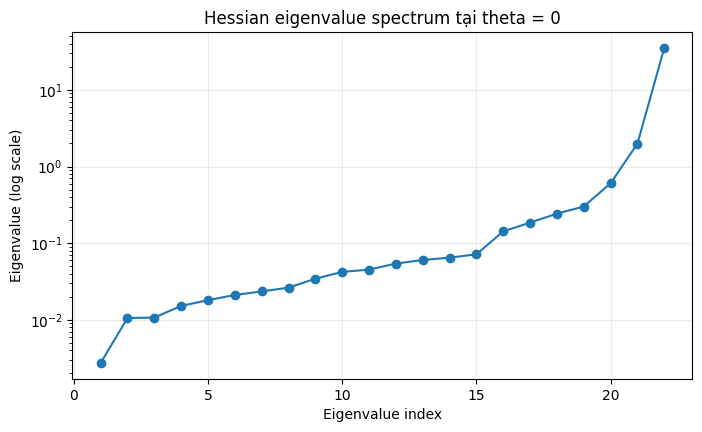

In [5]:
theta0 = np.zeros(X_train.shape[1] + 1)

H0 = bce_hessian(theta0, X_train, y_train)
eig0 = np.linalg.eigvalsh(H0)

H_upper = global_hessian_upper_bound(X_train, l2=0.0)
eig_upper = np.linalg.eigvalsh(H_upper)

L_global = float(eig_upper[-1])
eta_theory = 1.0 / L_global

geometry_initial = pd.Series({
    "lambda_min_H(theta0)": eig0[0],
    "lambda_max_H(theta0)": eig0[-1],
    "condition_number_H(theta0)": condition_number_from_eigs(eig0),
    "global_L_upper_bound": L_global,
    "1/L": eta_theory,
})
display(geometry_initial)

plt.figure(figsize=(8, 4.5))
plt.semilogy(np.arange(1, len(eig0) + 1), np.maximum(eig0, 1e-16), marker="o")
plt.xlabel("Eigenvalue index")
plt.ylabel("Eigenvalue (log scale)")
plt.title("Hessian eigenvalue spectrum tại theta = 0")
plt.grid(alpha=0.25)
plt.show()

## 3.1 Từ Hessian đến step size

Do \(p_i(1-p_i)\le 1/4\), ta có một global upper bound \(L\) cho Lipschitz constant của gradient.

\[
\eta_{\text{theory}}=\frac1L.
\]

**Kết luận:** \(1/L\) là scale step size có cơ sở lý thuyết, nhưng có thể bảo thủ.

# 4. Stage 1a — Ảnh hưởng của step size lên GD

**Thực nghiệm:** chạy GD với \(0.5/L,1/L,1.5/L,1.9/L\) và Armijo backtracking.

**Đo:** train objective, gradient norm, thời gian và trạng thái hội tụ.

**Mục đích:** kiểm tra step size từ Lipschitz bound có hợp lý không và backtracking có tận dụng local geometry tốt hơn không.

In [6]:
def make_record(name, iteration, theta, X, y, Xv, yv, start_time,
                l2=0.0, step_size=np.nan, function_evaluations=np.nan,
                data_passes=np.nan):
    f, g = bce_objective_grad(theta, X, y, l2=l2)
    fv, _ = bce_objective_grad(theta, Xv, yv, l2=0.0)
    return {
        "optimizer": name,
        "iteration": int(iteration),
        "train_objective": float(f),
        "validation_bce": float(fv),
        "gradient_norm": float(np.linalg.norm(g)),
        "step_size": float(step_size) if np.isfinite(step_size) else np.nan,
        "wall_time_seconds": float(time.perf_counter() - start_time),
        "function_evaluations": function_evaluations,
        "data_passes": data_passes,
    }

def gd_fixed(X, y, Xv, yv, lr, max_iter=500, tol=1e-5, l2=0.0, name=None):
    theta = np.zeros(X.shape[1] + 1)
    hist = []
    start = time.perf_counter()
    name = name or f"GD fixed (lr={lr:.6g})"

    hist.append(make_record(name, 0, theta, X, y, Xv, yv, start,
                            l2=l2, step_size=0.0, function_evaluations=1, data_passes=0))

    for k in range(1, max_iter + 1):
        _, g = bce_objective_grad(theta, X, y, l2=l2)
        theta = theta - lr * g

        row = make_record(name, k, theta, X, y, Xv, yv, start,
                          l2=l2, step_size=lr,
                          function_evaluations=k + 1, data_passes=k)
        hist.append(row)

        if not np.isfinite(row["train_objective"]):
            break
        if row["gradient_norm"] <= tol:
            break

    return theta, pd.DataFrame(hist)

def gd_backtracking(X, y, Xv, yv, max_iter=500, tol=1e-5,
                    l2=0.0, alpha0=1.0, rho=0.5, c=1e-4):
    theta = np.zeros(X.shape[1] + 1)
    hist = []
    start = time.perf_counter()
    func_evals = 0
    previous_step = alpha0
    name = "GD + Armijo"

    hist.append(make_record(name, 0, theta, X, y, Xv, yv, start,
                            l2=l2, step_size=0.0,
                            function_evaluations=func_evals, data_passes=0))

    for k in range(1, max_iter + 1):
        f, g = bce_objective_grad(theta, X, y, l2=l2)
        func_evals += 1
        gg = np.dot(g, g)

        # Cho phép thử tăng lại step nhưng chặn ở alpha0.
        step = min(previous_step / rho, alpha0)

        for _ in range(60):
            candidate = theta - step * g
            fc, _ = bce_objective_grad(candidate, X, y, l2=l2)
            func_evals += 1

            if fc <= f - c * step * gg:
                break
            step *= rho
        else:
            raise RuntimeError("Armijo line search không tìm được step hợp lệ.")

        theta = candidate
        previous_step = step

        row = make_record(name, k, theta, X, y, Xv, yv, start,
                          l2=l2, step_size=step,
                          function_evaluations=func_evals,
                          data_passes=np.nan)
        hist.append(row)

        if row["gradient_norm"] <= tol:
            break

    return theta, pd.DataFrame(hist)

In [7]:
gd_runs = {}
gd_models = {}

for factor in [0.5, 1.0, 1.5, 1.9]:
    lr = factor * eta_theory
    name = f"GD {factor:.1f}/L"
    theta, hist = gd_fixed(
        X_train, y_train, X_val, y_val,
        lr=lr,
        max_iter=GD_MAX_ITERS,
        tol=GRAD_TOL,
        name=name,
    )
    gd_runs[name] = hist
    gd_models[name] = theta

theta_armijo, hist_armijo = gd_backtracking(
    X_train, y_train, X_val, y_val,
    max_iter=GD_MAX_ITERS,
    tol=GRAD_TOL,
)
gd_runs["GD + Armijo"] = hist_armijo
gd_models["GD + Armijo"] = theta_armijo

gd_summary = pd.DataFrame([
    {
        "optimizer": name,
        "iterations": int(hist.iloc[-1]["iteration"]),
        "final_train_objective": hist.iloc[-1]["train_objective"],
        "final_validation_bce": hist.iloc[-1]["validation_bce"],
        "final_gradient_norm": hist.iloc[-1]["gradient_norm"],
        "converged": bool(hist.iloc[-1]["gradient_norm"] <= GRAD_TOL),
        "stop_reason": (
            "gradient tolerance"
            if hist.iloc[-1]["gradient_norm"] <= GRAD_TOL
            else "max iterations"
        ),
        "wall_time_seconds": hist.iloc[-1]["wall_time_seconds"],
        "last_step_size": hist.iloc[-1]["step_size"],
    }
    for name, hist in gd_runs.items()
]).sort_values("final_train_objective")

display(gd_summary)

,optimizer,iterations,final_train_objective,final_validation_bce,final_gradient_norm,converged,stop_reason,wall_time_seconds,last_step_size
4,GD + Armijo,500,0.376969,0.357789,0.010634,False,max iterations,156.960645,0.125000
3,GD 1.9/L,500,0.383379,0.363831,0.017175,False,max iterations,79.417903,0.053851
2,GD 1.5/L,500,0.385299,0.365647,0.019736,False,max iterations,75.769712,0.042514
1,GD 1.0/L,500,0.388796,0.368913,0.025268,False,max iterations,78.955988,0.028343
0,GD 0.5/L,500,0.396038,0.375501,0.041336,False,max iterations,83.693458,0.014171


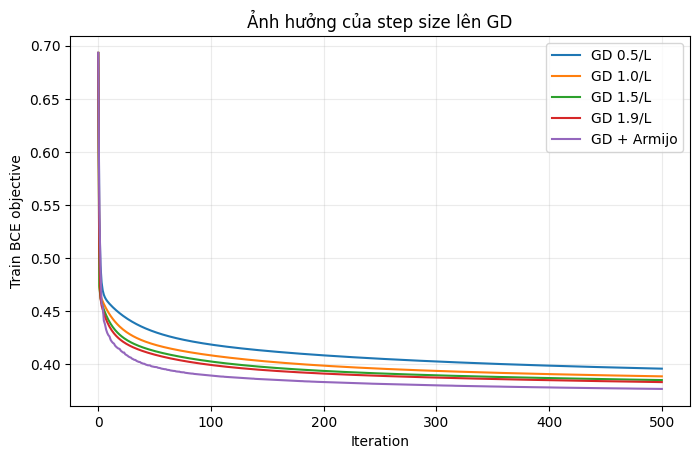

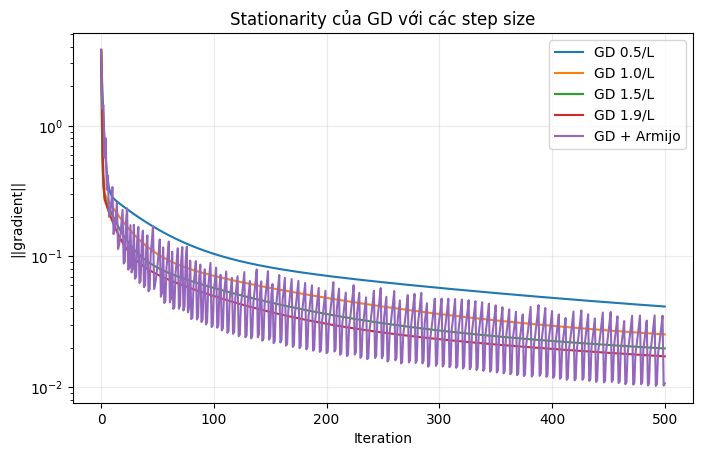

In [8]:
# Stage 1a chỉ so step size của GD, nên vẽ trực tiếp objective.
# Không dùng "best GD run" làm F* vì sẽ làm final point của best run có gap = 0 giả tạo.

plt.figure(figsize=(8, 4.8))
for name, hist in gd_runs.items():
    plt.plot(hist["iteration"], hist["train_objective"], label=name)
plt.xlabel("Iteration")
plt.ylabel("Train BCE objective")
plt.title("Ảnh hưởng của step size lên GD")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4.8))
for name, hist in gd_runs.items():
    plt.semilogy(
        hist["iteration"],
        np.maximum(hist["gradient_norm"], 1e-14),
        label=name
    )
plt.xlabel("Iteration")
plt.ylabel("||gradient||")
plt.title("Stationarity của GD với các step size")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

### Kết luận Stage 1a

Step lớn hơn trong vùng ổn định giúp GD tiến nhanh hơn. Armijo đạt objective thấp nhất trong các GD run và chấp nhận step lớn hơn \(1/L\), cho thấy global \(L\) khá bảo thủ.

**Quan trọng:** các GD run hiện tại đều dừng vì đạt `max_iter=500`, chưa đạt \(\|\nabla F\|\le10^{-5}\).

# 5. Stage 1b — So sánh GD, SGD, NAG và Newton

**Thực nghiệm:** giữ nguyên BCE, chỉ thay optimizer.

- GD: full-batch.
- SGD: mini-batch, fixed LR.
- NAG: full-batch + momentum.
- Newton: dùng Hessian + line search.

**Lưu ý:** 1 SGD epoch không bằng 1 GD/Newton iteration, nên không dùng số vòng lặp thô để xếp hạng tốc độ.

In [9]:
def sgd_minibatch(X, y, Xv, yv, lr, epochs=20, batch_size=512,
                  seed=42, l2=0.0):
    rng = np.random.default_rng(seed)
    theta = np.zeros(X.shape[1] + 1)
    hist = []
    start = time.perf_counter()
    updates = 0
    name = f"SGD lr={lr:g}"

    hist.append(make_record(name, 0, theta, X, y, Xv, yv, start,
                            l2=l2, step_size=lr,
                            function_evaluations=0, data_passes=0))

    for epoch in range(1, epochs + 1):
        perm = rng.permutation(len(y))

        for st in range(0, len(y), batch_size):
            idx = perm[st:st + batch_size]
            _, g = bce_objective_grad(theta, X[idx], y[idx], l2=l2)
            theta -= lr * g
            updates += 1

        row = make_record(name, epoch, theta, X, y, Xv, yv, start,
                          l2=l2, step_size=lr,
                          function_evaluations=updates, data_passes=epoch)
        hist.append(row)

    return theta, pd.DataFrame(hist)

## 5.2 Nesterov Accelerated Gradient

**Làm gì:** dùng momentum và gradient tại điểm look-ahead.

**Mục đích:** kiểm tra acceleration có giúp trên bài toán ill-conditioned hay không.

**Kết luận cần đọc:** so objective và gradient norm của NAG với GD trong cùng budget full-batch.

In [10]:
def nesterov(X, y, Xv, yv, lr, beta=0.9, max_iter=500,
             tol=1e-5, l2=0.0, name=None):
    theta = np.zeros(X.shape[1] + 1)
    velocity = np.zeros_like(theta)
    hist = []
    start = time.perf_counter()
    name = name or f"NAG lr={lr:.6g}"

    hist.append(make_record(name, 0, theta, X, y, Xv, yv, start,
                            l2=l2, step_size=lr,
                            function_evaluations=0, data_passes=0))

    for k in range(1, max_iter + 1):
        lookahead = theta + beta * velocity
        _, g = bce_objective_grad(lookahead, X, y, l2=l2)

        velocity = beta * velocity - lr * g
        theta = theta + velocity

        row = make_record(name, k, theta, X, y, Xv, yv, start,
                          l2=l2, step_size=lr,
                          function_evaluations=k, data_passes=k)
        hist.append(row)

        if not np.isfinite(row["train_objective"]):
            break
        if row["gradient_norm"] <= tol:
            break

    return theta, pd.DataFrame(hist)

## 5.3 Damped Newton

Newton giải:

\[
H_k d_k=g_k,\qquad \theta_{k+1}=\theta_k-\alpha_kd_k.
\]

**Làm gì:** dùng Hessian để rescale các hướng curvature; Armijo chọn \(\alpha_k\).

**Kết luận cần đọc:** với chỉ 21 feature, Hessian nhỏ nên Newton là second-order benchmark phù hợp.

In [11]:
def newton_damped(X, y, Xv, yv, max_iter=30, tol=1e-5,
                  l2=0.0, damping=1e-10, c=1e-4, rho=0.5,
                  name=None):
    theta = np.zeros(X.shape[1] + 1)
    hist = []
    start = time.perf_counter()
    func_evals = 0
    name = name or ("Newton damped" if l2 == 0 else f"Newton L2={l2:g}")

    hist.append(make_record(name, 0, theta, X, y, Xv, yv, start,
                            l2=l2, step_size=0.0,
                            function_evaluations=func_evals, data_passes=0))

    for k in range(1, max_iter + 1):
        f, g = bce_objective_grad(theta, X, y, l2=l2)
        func_evals += 1
        H = bce_hessian(theta, X, y, l2=l2)

        # solve(H d = g) thay vì tính inverse(H)
        direction = np.linalg.solve(H + damping * np.eye(len(theta)), g)

        step = 1.0
        directional_decrease = np.dot(g, direction)

        for _ in range(60):
            candidate = theta - step * direction
            fc, _ = bce_objective_grad(candidate, X, y, l2=l2)
            func_evals += 1
            if fc <= f - c * step * directional_decrease:
                break
            step *= rho
        else:
            raise RuntimeError("Newton line search không tìm được step hợp lệ.")

        theta = candidate

        row = make_record(name, k, theta, X, y, Xv, yv, start,
                          l2=l2, step_size=step,
                          function_evaluations=func_evals,
                          data_passes=np.nan)
        hist.append(row)

        if row["gradient_norm"] <= tol:
            break

    return theta, pd.DataFrame(hist)

In [12]:
# --- Tune NAG trên scale của 1/L ---
nag_runs = {}
nag_models = {}

for factor in [0.5, 1.0, 1.5, 1.9]:
    lr = factor * eta_theory
    name = f"NAG {factor:.1f}/L"
    theta, hist = nesterov(
        X_train, y_train, X_val, y_val,
        lr=lr,
        beta=0.9,
        max_iter=NAG_MAX_ITERS,
        tol=GRAD_TOL,
        name=name,
    )
    nag_runs[name] = hist
    nag_models[name] = theta

best_nag_name = min(
    nag_runs,
    key=lambda k: nag_runs[k].iloc[-1]["train_objective"]
)

# --- Tune SGD riêng ---
sgd_runs = {}
sgd_models = {}

for lr in [0.001, 0.003, 0.01, 0.03, 0.1]:
    theta, hist = sgd_minibatch(
        X_train, y_train, X_val, y_val,
        lr=lr,
        epochs=SGD_EPOCHS,
        batch_size=BATCH_SIZE,
        seed=SEED,
    )
    name = f"SGD lr={lr:g}"
    sgd_runs[name] = hist
    sgd_models[name] = theta

best_sgd_name = min(
    sgd_runs,
    key=lambda k: sgd_runs[k].iloc[-1]["train_objective"]
)

# --- Newton ---
theta_newton, hist_newton = newton_damped(
    X_train, y_train, X_val, y_val,
    max_iter=NEWTON_MAX_ITERS,
    tol=GRAD_TOL,
)

# Best GD run theo objective cuối
best_gd_name = min(
    gd_runs,
    key=lambda k: gd_runs[k].iloc[-1]["train_objective"]
)

selected_histories = {
    best_gd_name: gd_runs[best_gd_name],
    best_nag_name: nag_runs[best_nag_name],
    best_sgd_name: sgd_runs[best_sgd_name],
    "Newton damped": hist_newton,
}

selected_models = {
    best_gd_name: gd_models[best_gd_name],
    best_nag_name: nag_models[best_nag_name],
    best_sgd_name: sgd_models[best_sgd_name],
    "Newton damped": theta_newton,
}

def optimizer_status(name, hist):
    gnorm = float(hist.iloc[-1]["gradient_norm"])
    if gnorm <= GRAD_TOL:
        return True, "converged"
    if name.startswith("SGD"):
        return False, "epoch budget; fixed-LR stochastic, not stationary"
    return False, "max_iter reached; not converged"

optimizer_rows = []
for name, hist in selected_histories.items():
    converged, status = optimizer_status(name, hist)
    optimizer_rows.append({
        "optimizer": name,
        "iterations_or_epochs": int(hist.iloc[-1]["iteration"]),
        "final_train_objective": hist.iloc[-1]["train_objective"],
        "final_validation_bce": hist.iloc[-1]["validation_bce"],
        "final_gradient_norm": hist.iloc[-1]["gradient_norm"],
        "converged": converged,
        "status": status,
        "wall_time_seconds": hist.iloc[-1]["wall_time_seconds"],
    })

optimizer_summary = pd.DataFrame(optimizer_rows).sort_values(
    ["converged", "final_train_objective", "wall_time_seconds"],
    ascending=[False, True, True]
)

display(optimizer_summary)

# Chỉ gọi một optimizer là opt* nếu nó thực sự đạt stationarity tolerance.
converged_candidates = optimizer_summary[optimizer_summary["converged"]]

if len(converged_candidates):
    opt_star = converged_candidates.sort_values(
        ["final_train_objective", "wall_time_seconds"],
        ascending=[True, True]
    ).iloc[0]["optimizer"]
else:
    # Fallback: nếu không run nào đạt tolerance thì chỉ chọn best-found objective.
    opt_star = optimizer_summary.sort_values(
        ["final_train_objective", "wall_time_seconds"],
        ascending=[True, True]
    ).iloc[0]["optimizer"]

print("opt* (ưu tiên run đã hội tụ):", opt_star)

,optimizer,iterations_or_epochs,final_train_objective,final_validation_bce,final_gradient_norm,converged,status,wall_time_seconds
3,Newton damped,6,0.360182,0.344727,1.408388e-08,True,converged,4.187968
2,SGD lr=0.1,20,0.363042,0.347170,2.857691e-01,False,"epoch budget; fixed-LR stochastic, not stationary",30.961974
1,NAG 1.9/L,500,0.369219,0.351253,4.557216e-03,False,max_iter reached; not converged,90.450035
0,GD + Armijo,500,0.376969,0.357789,1.063410e-02,False,max_iter reached; not converged,156.960645


opt* (ưu tiên run đã hội tụ): Newton damped


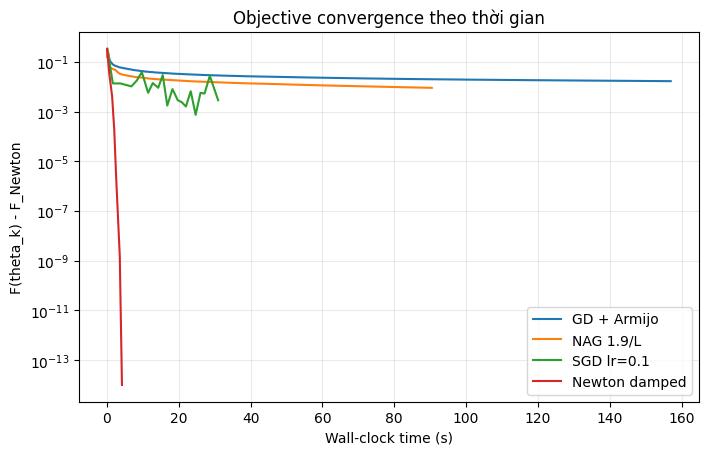

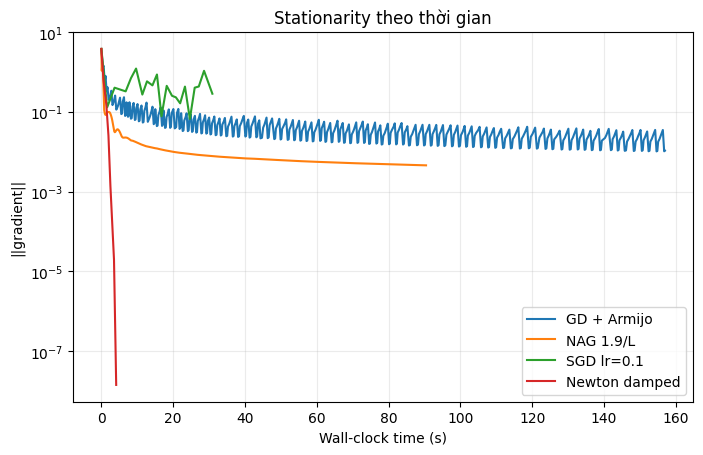

In [13]:
# Newton đạt gradient norm rất nhỏ nên dùng làm best-found reference.
F_star_ref = bce_objective_grad(
    theta_newton, X_train, y_train, l2=0.0
)[0]

plt.figure(figsize=(8, 4.8))
for name, hist in selected_histories.items():
    gap = np.maximum(
        hist["train_objective"].to_numpy() - F_star_ref,
        1e-14
    )
    plt.semilogy(
        hist["wall_time_seconds"],
        gap,
        label=name
    )
plt.xlabel("Wall-clock time (s)")
plt.ylabel("F(theta_k) - F_Newton")
plt.title("Objective convergence theo thời gian")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4.8))
for name, hist in selected_histories.items():
    plt.semilogy(
        hist["wall_time_seconds"],
        np.maximum(hist["gradient_norm"], 1e-14),
        label=name
    )
plt.xlabel("Wall-clock time (s)")
plt.ylabel("||gradient||")
plt.title("Stationarity theo thời gian")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

### Kết luận Stage 1

Từ lần chạy hiện tại:

- **Newton:** đạt objective thấp nhất và \(\|\nabla F\|\approx10^{-8}\) → đã hội tụ.
- **NAG/GD:** chưa đạt tolerance sau 500 iterations.
- **SGD fixed LR:** đạt vùng objective tốt nhanh nhưng full-gradient norm còn lớn → chưa stationary.

**Chọn \(opt^\star\): Damped Newton.**

Wall-clock time trong notebook có cả chi phí logging/line-search, nên chỉ dùng như empirical comparison.

# 6. Hessian tại nghiệm

**Thực nghiệm:** tính Hessian tại nghiệm Newton thay vì chỉ tại \(\theta=0\).

**Mục đích:** geometry thay đổi theo \(\theta\), nên conditioning gần nghiệm mới phản ánh độ khó ở giai đoạn hội tụ.

F(theta*)                     3.601823e-01
||grad F(theta*)||            1.408388e-08
lambda_min_H(theta*)          4.076885e-04
lambda_max_H(theta*)          1.769943e+01
condition_number_H(theta*)    4.341409e+04
dtype: float64

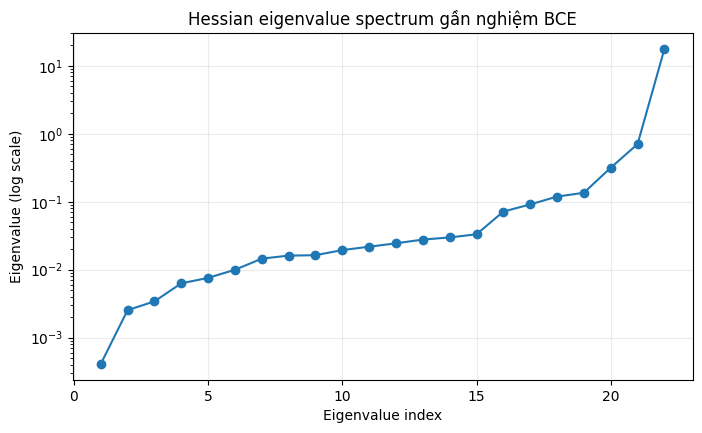

In [14]:
H_star = bce_hessian(theta_newton, X_train, y_train, l2=0.0)
eig_star = np.linalg.eigvalsh(H_star)

geometry_at_solution = pd.Series({
    "F(theta*)": bce_objective_grad(theta_newton, X_train, y_train)[0],
    "||grad F(theta*)||": np.linalg.norm(
        bce_objective_grad(theta_newton, X_train, y_train)[1]
    ),
    "lambda_min_H(theta*)": eig_star[0],
    "lambda_max_H(theta*)": eig_star[-1],
    "condition_number_H(theta*)": condition_number_from_eigs(eig_star),
})
display(geometry_at_solution)

plt.figure(figsize=(8, 4.5))
plt.semilogy(
    np.arange(1, len(eig_star) + 1),
    np.maximum(eig_star, 1e-16),
    marker="o"
)
plt.xlabel("Eigenvalue index")
plt.ylabel("Eigenvalue (log scale)")
plt.title("Hessian eigenvalue spectrum gần nghiệm BCE")
plt.grid(alpha=0.25)
plt.show()

### Kết luận

Condition number gần nghiệm lớn hơn lúc khởi tạo.

**Kết luận:** BCE vẫn lồi nhưng geometry gần nghiệm còn ill-conditioned hơn, giải thích vì sao first-order methods tiếp tục tiến chậm.

# 7. Stage 3 — L2 thay đổi geometry

Thêm:

\[
F_\lambda(w,b)=F(w,b)+\frac{\lambda}{2}\|w\|^2.
\]

Vì bias không regularize, spectral shift chính xác được phân tích trên weight block:

\[
H_{ww,\lambda}=H_{ww}+\lambda I.
\]

**Mục tiêu:** kiểm tra L2 có cải thiện conditioning và convergence hay không.

## 7.1 Spectral shift tại cùng một điểm

**Thực nghiệm:** giữ nguyên nghiệm BCE và cộng \(\lambda I\) vào weight Hessian.

**Đo:** eigenvalue spectrum và condition number.

**Mục đích:** kiểm chứng trực tiếp cơ chế hình học của L2.

,lambda,lambda_min_weight_block,lambda_max_weight_block,condition_weight_block
0,0.000,0.001955,17.591336,8997.400443
1,0.001,0.002955,17.592336,5953.095673
2,0.010,0.011955,17.601336,1472.279714
3,0.100,0.101955,17.691336,173.520756
4,1.000,1.001955,18.591336,18.555058


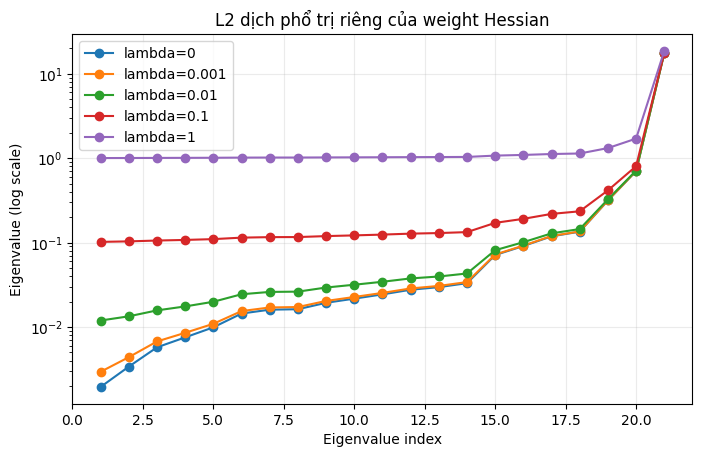

In [15]:
Hww_ref = H_star[:-1, :-1]
eig_ww_ref = np.linalg.eigvalsh(Hww_ref)

geometry_lambdas = [0.0, 1e-3, 1e-2, 1e-1, 1.0]

shift_rows = []
plt.figure(figsize=(8, 4.8))

for lam in geometry_lambdas:
    eig_shift = np.linalg.eigvalsh(Hww_ref + lam * np.eye(Hww_ref.shape[0]))
    shift_rows.append({
        "lambda": lam,
        "lambda_min_weight_block": eig_shift[0],
        "lambda_max_weight_block": eig_shift[-1],
        "condition_weight_block": condition_number_from_eigs(eig_shift),
    })
    plt.semilogy(
        np.arange(1, len(eig_shift) + 1),
        np.maximum(eig_shift, 1e-16),
        marker="o",
        label=f"lambda={lam:g}"
    )

shift_table = pd.DataFrame(shift_rows)
display(shift_table)

plt.xlabel("Eigenvalue index")
plt.ylabel("Eigenvalue (log scale)")
plt.title("L2 dịch phổ trị riêng của weight Hessian")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

### Kết luận

Khi \(\lambda\) tăng, trị riêng nhỏ được nâng lên mạnh và condition number giảm rõ rệt.

**Kết luận:** L2 làm weight-space geometry dễ tối ưu hơn.

## 7.2 Re-optimize với từng \(\lambda\)

**Thực nghiệm:** giải lại BCE + L2 cho từng \(\lambda\), sau đó đo cả conditioning và validation metrics.

**Mục đích:** tách hai câu hỏi:
1. L2 có làm optimization dễ hơn không?
2. L2 có làm prediction tốt hơn không?

In [16]:
def choose_threshold_max_f1(y_true, prob):
    precision, recall, thresholds = precision_recall_curve(y_true, prob)

    # precision/recall dài hơn thresholds 1 phần tử.
    if len(thresholds) == 0:
        return 0.5

    p = precision[:-1]
    r = recall[:-1]
    f1 = 2 * p * r / np.maximum(p + r, 1e-15)
    idx = int(np.nanargmax(f1))
    return float(thresholds[idx])

def prediction_metrics(y_true, prob, threshold):
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()

    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1_minority": f1_score(y_true, pred, zero_division=0),
        "auroc": roc_auc_score(y_true, prob),
        "auprc": average_precision_score(y_true, prob),
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "cost_5FN_plus_FP": int(5 * fn + fp),
    }

In [17]:
l2_grid = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
l2_models = {}
l2_histories = {}
l2_rows = []

for lam in l2_grid:
    if lam == 0.0:
        theta_lam = theta_newton.copy()
        hist_lam = hist_newton.copy()
    else:
        theta_lam, hist_lam = newton_damped(
            X_train, y_train, X_val, y_val,
            max_iter=NEWTON_MAX_ITERS,
            tol=GRAD_TOL,
            l2=lam,
            name=f"Newton L2={lam:g}",
        )

    l2_models[lam] = theta_lam
    l2_histories[lam] = hist_lam

    val_prob = sigmoid(X_val @ theta_lam[:-1] + theta_lam[-1])
    threshold = choose_threshold_max_f1(y_val, val_prob)
    pm = prediction_metrics(y_val, val_prob, threshold)

    H_lam = bce_hessian(theta_lam, X_train, y_train, l2=lam)
    eig_full = np.linalg.eigvalsh(H_lam)
    eig_ww = np.linalg.eigvalsh(H_lam[:-1, :-1])

    l2_rows.append({
        "lambda": lam,
        "train_objective": bce_objective_grad(
            theta_lam, X_train, y_train, l2=lam
        )[0],
        "full_grad_norm": np.linalg.norm(
            bce_objective_grad(theta_lam, X_train, y_train, l2=lam)[1]
        ),
        "full_hessian_min": eig_full[0],
        "full_hessian_max": eig_full[-1],
        "full_condition_number": condition_number_from_eigs(eig_full),
        "weight_condition_number": condition_number_from_eigs(eig_ww),
        **pm,
    })

l2_results = pd.DataFrame(l2_rows)
display(l2_results)

,lambda,train_objective,full_grad_norm,full_hessian_min,full_hessian_max,full_condition_number,weight_condition_number,threshold,accuracy,precision,recall,f1_minority,auroc,auprc,tp,tn,fp,fn,cost_5FN_plus_FP
0,0.0000,0.360182,1.408388e-08,0.000408,17.699427,43414.091541,8997.400443,0.208340,0.774374,0.358733,0.628347,0.456719,0.804087,0.404498,10489,75156,18750,6204,49770
1,0.0001,0.360372,9.037691e-06,0.000479,17.712112,36986.393847,8256.065474,0.208187,0.774320,0.358602,0.627988,0.456517,0.804116,0.404456,10483,75156,18750,6210,49800
2,0.0010,0.361639,8.269530e-07,0.000831,17.797421,21426.415044,5201.789937,0.205708,0.773000,0.357489,0.632121,0.456698,0.803948,0.403910,10552,74941,18965,6141,49670
3,0.0100,0.368002,1.529230e-07,0.001576,18.248450,11575.860472,1383.735170,0.195156,0.764320,0.349071,0.649314,0.454047,0.801781,0.399028,10839,73694,20212,5854,49482
4,0.1000,0.389413,1.166081e-09,0.003249,19.495529,6000.443968,186.358566,0.188242,0.750513,0.331384,0.641646,0.437050,0.788396,0.375331,10711,72295,21611,5982,51521
5,1.0000,0.421591,1.805793e-07,0.010692,21.007627,1964.885407,20.782093,0.176436,0.705024,0.286098,0.638232,0.395090,0.749829,0.317770,10654,67321,26585,6039,56780


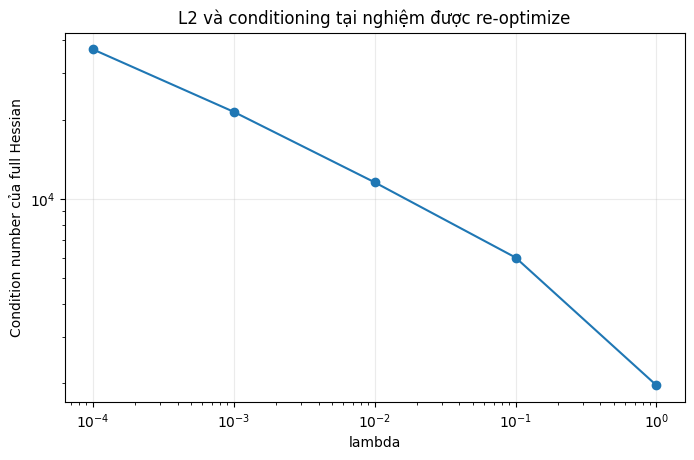

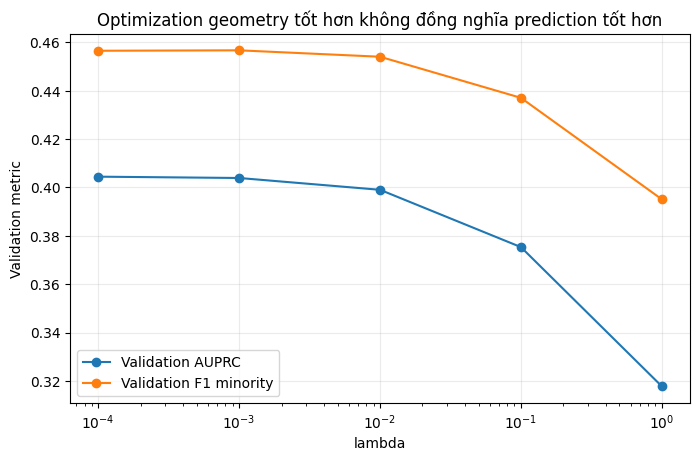

In [18]:
plt.figure(figsize=(8, 4.8))
positive_lams = l2_results["lambda"] > 0
plot_df = l2_results[positive_lams]
plt.loglog(
    plot_df["lambda"],
    plot_df["full_condition_number"],
    marker="o"
)
plt.xlabel("lambda")
plt.ylabel("Condition number của full Hessian")
plt.title("L2 và conditioning tại nghiệm được re-optimize")
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(8, 4.8))
plt.semilogx(
    plot_df["lambda"],
    plot_df["auprc"],
    marker="o",
    label="Validation AUPRC"
)
plt.semilogx(
    plot_df["lambda"],
    plot_df["f1_minority"],
    marker="o",
    label="Validation F1 minority"
)
plt.xlabel("lambda")
plt.ylabel("Validation metric")
plt.title("Optimization geometry tốt hơn không đồng nghĩa prediction tốt hơn")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## 7.3 L2 có làm GD hội tụ nhanh hơn không?

**Thực nghiệm:** so GD \(1/L\) cho BCE và BCE+\(L2\) với \(\lambda=0.1\).

Dùng normalized objective gap:

\[
\frac{F(\theta_k)-F^\star}{F(\theta_0)-F^\star}.
\]

**Mục đích:** nối trực tiếp
\[
\kappa\downarrow \rightarrow \text{GD convergence tốt hơn}.
\]

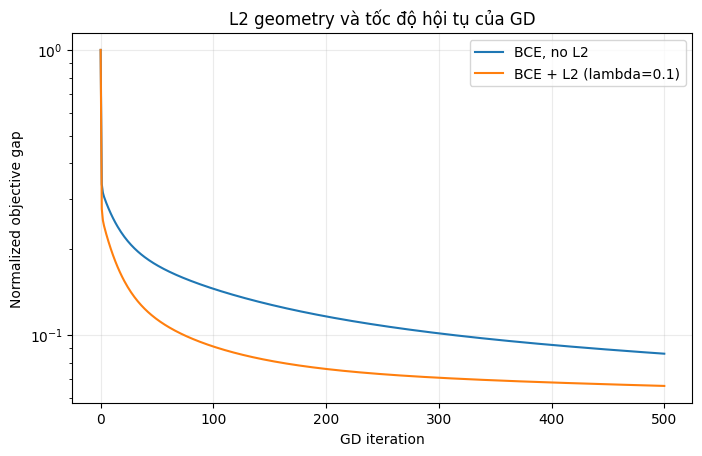

,objective,L_bound,step_1_over_L,iterations_to_rel_gap_2e-1,iterations_to_rel_gap_1e-1,final_relative_gap
0,BCE,35.282567,0.028343,31,312,0.085936
1,BCE + L2 lambda=0.1,35.381893,0.028263,10,74,0.066239


In [19]:
LAMBDA_GEOMETRY_DEMO = 0.1

# Unregularized GD 1/L đã chạy ở Stage 1.
unreg_name = "GD 1.0/L"
hist_unreg = gd_runs[unreg_name]
theta_ref_unreg = theta_newton
Fstar_unreg = bce_objective_grad(theta_ref_unreg, X_train, y_train, l2=0.0)[0]

# L2 reference bằng Newton.
theta_ref_l2 = l2_models[LAMBDA_GEOMETRY_DEMO]
Fstar_l2 = bce_objective_grad(
    theta_ref_l2, X_train, y_train, l2=LAMBDA_GEOMETRY_DEMO
)[0]

H_upper_l2 = global_hessian_upper_bound(
    X_train, l2=LAMBDA_GEOMETRY_DEMO
)
L_l2 = float(np.linalg.eigvalsh(H_upper_l2)[-1])
eta_l2 = 1.0 / L_l2

theta_gd_l2, hist_gd_l2 = gd_fixed(
    X_train, y_train, X_val, y_val,
    lr=eta_l2,
    max_iter=GD_MAX_ITERS,
    tol=GRAD_TOL,
    l2=LAMBDA_GEOMETRY_DEMO,
    name=f"GD L2={LAMBDA_GEOMETRY_DEMO:g}, 1/L_lambda",
)

def normalized_gap(hist, Fstar):
    f = hist["train_objective"].to_numpy()
    denom = max(f[0] - Fstar, 1e-15)
    return np.maximum((f - Fstar) / denom, 1e-15)

gap_unreg = normalized_gap(hist_unreg, Fstar_unreg)
gap_l2 = normalized_gap(hist_gd_l2, Fstar_l2)

plt.figure(figsize=(8, 4.8))
plt.semilogy(hist_unreg["iteration"], gap_unreg, label="BCE, no L2")
plt.semilogy(
    hist_gd_l2["iteration"],
    gap_l2,
    label=f"BCE + L2 (lambda={LAMBDA_GEOMETRY_DEMO:g})"
)
plt.xlabel("GD iteration")
plt.ylabel("Normalized objective gap")
plt.title("L2 geometry và tốc độ hội tụ của GD")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

def iteration_to_gap(hist, gap, target):
    idx = np.where(gap <= target)[0]
    return int(hist.iloc[idx[0]]["iteration"]) if len(idx) else np.nan

convergence_l2_demo = pd.DataFrame([
    {
        "objective": "BCE",
        "L_bound": L_global,
        "step_1_over_L": eta_theory,
        "iterations_to_rel_gap_2e-1": iteration_to_gap(hist_unreg, gap_unreg, 2e-1),
        "iterations_to_rel_gap_1e-1": iteration_to_gap(hist_unreg, gap_unreg, 1e-1),
        "final_relative_gap": float(gap_unreg[-1]),
    },
    {
        "objective": f"BCE + L2 lambda={LAMBDA_GEOMETRY_DEMO:g}",
        "L_bound": L_l2,
        "step_1_over_L": eta_l2,
        "iterations_to_rel_gap_2e-1": iteration_to_gap(hist_gd_l2, gap_l2, 2e-1),
        "iterations_to_rel_gap_1e-1": iteration_to_gap(hist_gd_l2, gap_l2, 1e-1),
        "final_relative_gap": float(gap_l2[-1]),
    },
])

display(convergence_l2_demo)

### Kết luận phần L2

L2 làm condition number giảm mạnh và giúp GD tiến nhanh hơn theo normalized gap.

Tuy nhiên \(\lambda\) lớn làm validation F1/AUPRC giảm.

**Kết luận:** optimization geometry tốt hơn không đồng nghĩa prediction tốt hơn.

# 8. Chọn regularization trên validation

**Rule:** ưu tiên F1 minority, AUPRC dùng tie-break.

**Kết quả hiện tại:** \(\lambda^\star=0\). \(\lambda=10^{-3}\) gần như tương đương, nhưng L2 mạnh hơn bắt đầu làm prediction giảm.

**Lưu ý:** cost \(5FN+FP\) chỉ là metric phụ, không dùng để chọn \(\lambda^\star\).

In [20]:
reg_star_row = l2_results.sort_values(
    ["f1_minority", "auprc"],
    ascending=[False, False]
).iloc[0]

reg_star_lambda = float(reg_star_row["lambda"])
theta_final = l2_models[reg_star_lambda]
threshold_final = float(reg_star_row["threshold"])

print("Selected lambda* =", reg_star_lambda)
print("Validation threshold* =", threshold_final)

display(
    reg_star_row[
        [
            "lambda",
            "f1_minority",
            "auprc",
            "recall",
            "precision",
            "full_condition_number",
        ]
    ]
)

Selected lambda* = 0.0
Validation threshold* = 0.20833957658872537


lambda                       0.000000
f1_minority                  0.456719
auprc                        0.404498
recall                       0.628347
precision                    0.358733
full_condition_number    43414.091541
Name: 0, dtype: float64

# 9. Stage 4 — Đánh giá test

Sau khi khóa:

- loss = BCE,
- optimizer = Damped Newton,
- \(\lambda^\star\) từ validation,
- threshold từ validation,

mới load test.

**Mục tiêu:** đánh giá khả năng generalize của cấu hình cuối mà không dùng test để tune.

In [21]:
TEST_PATH = resolve_csv("test.csv")
test_df = pd.read_csv(TEST_PATH)

test_feature_cols = [c for c in test_df.columns if c != TARGET_COL]
if test_feature_cols != feature_cols:
    raise ValueError("Feature schema/order của test không giống train.")

X_test = test_df[feature_cols].to_numpy(dtype=np.float64)
y_test = test_df[TARGET_COL].to_numpy(dtype=np.float64)

test_prob = sigmoid(X_test @ theta_final[:-1] + theta_final[-1])
test_metrics = prediction_metrics(
    y_test, test_prob, threshold=threshold_final
)

test_results_df = pd.DataFrame([test_metrics])
display(test_results_df)

,threshold,accuracy,precision,recall,f1_minority,auroc,auprc,tp,tn,fp,fn,cost_5FN_plus_FP
0,0.20834,0.77464,0.358966,0.624731,0.455948,0.804271,0.407365,10433,75150,18631,6267,49966


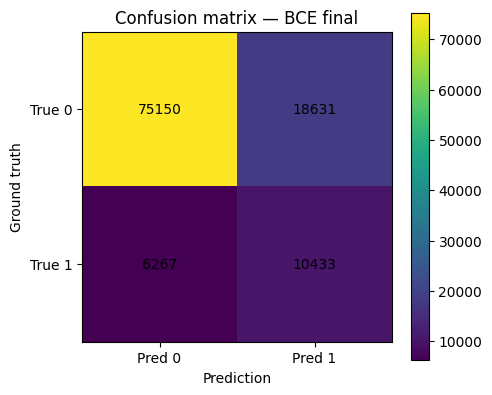

In [22]:
cm = np.array([
    [test_metrics["tn"], test_metrics["fp"]],
    [test_metrics["fn"], test_metrics["tp"]],
])

plt.figure(figsize=(5, 4.5))
plt.imshow(cm)
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])
plt.title("Confusion matrix — BCE final")
plt.xlabel("Prediction")
plt.ylabel("Ground truth")

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.colorbar()
plt.show()

# 10. So sánh với sklearn

**Thực nghiệm:** train `sklearn.LogisticRegression` trên cùng frozen train split và so test metrics.

**Mục đích:** kiểm tra nghiệm NumPy tự cài đặt có khớp với solver chuẩn hay không.

In [23]:
from sklearn.linear_model import LogisticRegression

if reg_star_lambda > 0:
    C = 1.0 / (len(y_train) * reg_star_lambda)
    clf = LogisticRegression(
        penalty="l2",
        C=C,
        solver="lbfgs",
        fit_intercept=True,
        max_iter=2000,
        tol=1e-8,
    )
else:
    C = None
    clf = LogisticRegression(
        penalty=None,
        solver="lbfgs",
        fit_intercept=True,
        max_iter=2000,
        tol=1e-8,
    )

clf.fit(X_train, y_train)
sk_prob = clf.predict_proba(X_test)[:, 1]
sk_metrics = prediction_metrics(
    y_test, sk_prob, threshold=threshold_final
)

comparison = pd.DataFrame([
    {"implementation": "Custom NumPy", **test_metrics},
    {"implementation": "sklearn", **sk_metrics},
])

display(comparison)
print("sklearn C =", C)

,implementation,threshold,accuracy,precision,recall,f1_minority,auroc,auprc,tp,tn,fp,fn,cost_5FN_plus_FP
0,Custom NumPy,0.20834,0.774640,0.358966,0.624731,0.455948,0.804271,0.407365,10433,75150,18631,6267,49966
1,sklearn,0.20834,0.774613,0.358929,0.624731,0.455918,0.804271,0.407364,10433,75147,18634,6267,49969


sklearn C = None


# 11. Kết luận từ lần chạy hiện tại

- BCE convex/smooth nhưng Hessian ill-conditioned.
- \(1/L\) là step an toàn nhưng bảo thủ; Armijo dùng được step lớn hơn.
- Damped Newton là optimizer duy nhất đạt stationarity tolerance trong budget hiện tại.
- L2 giảm condition number rất mạnh nhưng không cải thiện validation F1 trên dữ liệu này.
- Final BCE chọn **Newton + no L2**.
- Custom NumPy và sklearn cho kết quả gần như trùng nhau.

# 12. Storyline thuyết trình

\[
\boxed{
\text{BCE lồi, trơn}
\rightarrow
Hessian
\rightarrow
\kappa\text{ lớn}
\rightarrow
\text{GD nhạy step}
\rightarrow
\text{NAG/Newton}
\rightarrow
L2:\kappa\downarrow
\rightarrow
\text{convergence tốt hơn}
\rightarrow
\text{prediction không nhất thiết tốt hơn}
}
\]

# 13. Xuất kết quả

**Làm gì:** lưu các bảng Stage 1, Stage 3 và Stage 4 ra CSV/JSON.

**Mục đích:** dùng lại số liệu khi làm slide mà không phải chạy lại toàn bộ notebook.

In [24]:
gd_summary.to_csv(OUTPUT_DIR / "stage1_gd_step_size_summary.csv", index=False)
optimizer_summary.to_csv(OUTPUT_DIR / "stage1_optimizer_summary.csv", index=False)
l2_results.to_csv(OUTPUT_DIR / "stage3_l2_summary.csv", index=False)
test_results_df.to_csv(OUTPUT_DIR / "stage4_test_metrics.csv", index=False)
comparison.to_csv(OUTPUT_DIR / "stage4_library_comparison.csv", index=False)

run_summary = {
    "seed": SEED,
    "n_train": int(len(y_train)),
    "n_validation": int(len(y_val)),
    "n_test": int(len(y_test)),
    "n_features": int(X_train.shape[1]),
    "global_L": float(L_global),
    "inverse_L": float(eta_theory),
    "selected_optimizer_stage1": str(opt_star),
    "selected_lambda": float(reg_star_lambda),
    "selected_threshold": float(threshold_final),
    "test_metrics": {
        k: (int(v) if isinstance(v, (np.integer,)) else float(v))
        for k, v in test_metrics.items()
    },
}

with open(OUTPUT_DIR / "bce_run_summary.json", "w", encoding="utf-8") as f:
    json.dump(run_summary, f, indent=2, ensure_ascii=False)

print("Đã lưu kết quả vào:", OUTPUT_DIR.resolve())

Đã lưu kết quả vào: /Users/hoaithuong/gktuh/optimization/bce_experiment_outputs


---
## Appendix — Vì sao không chạy L1 trong luồng chính?

L1 không trơn tại 0 và cần proximal method.

**Kết luận:** để giữ câu chuyện BCE → Hessian → Newton → L2 liên tục, notebook chính chỉ dùng None/L2; L1 để phần mở rộng.